In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/teams.csv")

awards_players = pd.read_csv("../dataset/awards_players.csv")

players_teams = pd.read_csv("../dataset/players_teams.csv")

coaches = pd.read_csv("../dataset/coaches.csv")

df.head()

,year,lgID,tmID,franchID,confID,divID,rank,playoff,seeded,firstRound,...,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend,arena
0,9,WNBA,ATL,ATL,EA,NaN,7,N,0,NaN,...,34,1,16,3,14,2,18,6825,141379,Philips Arena
1,10,WNBA,ATL,ATL,EA,NaN,2,Y,0,L,...,34,12,5,6,11,10,12,6950,120737,Philips Arena
2,1,WNBA,CHA,CHA,EA,NaN,8,N,0,NaN,...,32,5,11,3,13,5,16,6475,90963,Charlotte Coliseum
3,2,WNBA,CHA,CHA,EA,NaN,4,Y,0,W,...,32,11,5,7,9,15,6,6500,105525,Charlotte Coliseum
4,3,WNBA,CHA,CHA,EA,NaN,2,Y,0,L,...,32,11,5,7,9,12,9,6450,106670,Charlotte Coliseum


In [130]:
# Calculate the number of player awards per team each year
filtered_awards = awards_players[awards_players['award'] != "Coach of the Year"]

award_counts = filtered_awards.groupby(['playerID', 'year']).size().reset_index(name='award_count')

player_team_awards = pd.merge(award_counts, players_teams, on=['playerID', 'year'], how='left')

team_awards = player_team_awards.groupby(['tmID', 'year'])['award_count'].sum().reset_index()

df = pd.merge(df, team_awards[['tmID', 'year', 'award_count']], on=['tmID', 'year'], how='left')

df['award_count'] = df['award_count'].fillna(0).astype(int)

In [131]:
# Measures how much a team outscores its opponents per game
df["net_rating"] = (df["o_pts"] - df["d_pts"]) / df["GP"]

df["off_eff"] = df["o_pts"] / df["o_fga"]   # points per field goal attempt
df["def_eff"] = df["d_pts"] / df["d_fga"]   # points allowed per opponent FGA

# Measures how effectively the team scores compared to what they allow
df["eff_diff"] = df["off_eff"] - df["def_eff"]

# Calculate the Home vs Away Win Ratio (small gap means consistency)
df["home_win_pct"] = df["homeW"] / (df["homeW"] + df["homeL"])
df["away_win_pct"] = df["awayW"] / (df["awayW"] + df["awayL"])
df["home_away_balance"] = df["away_win_pct"] - df["home_win_pct"]

# Calculate the difference between the turnovers of the opponents and the turnovers of the team
df["to_dif"] = df["d_to"] - df["o_to"]

# Calculate the difference between the rebounds gained by the team and the ones gained by the opponents
df["reb_dif"] = df["o_reb"] - df["d_reb"]

# Calculate the offensive rebound difference (extra scoring opportunities created by the team)
df["off_reb_dif"] = df["o_oreb"] - df["d_dreb"]

# Calculate the defensive rebound difference (how well the team prevents second-chance points)
df["def_reb_dif"] = df["o_dreb"] - df["d_oreb"]

# Calculate the percentage of all total rebounds captured by the team
df["reb_pct"] = df["o_reb"] / (df["o_reb"] + df["d_reb"])

# Calculate the percentage of offensive rebounds captured by the team (offensive efficiency)
df["off_reb_pct"] = df["o_oreb"] / (df["o_oreb"] + df["d_dreb"])

# Calculate the percentage of defensive rebounds captured by the team (defensive efficiency)
df["def_reb_pct"] = df["o_dreb"] / (df["o_dreb"] + df["d_oreb"])

# Calculate the percentage of conference wins per team
df["conf_win_pct"] = df["confW"] / (df["confW"] + df["confL"])

# Calculate the difference in assists between the team and its opponents
df["ast_dif"] = df["o_asts"] - df["d_asts"]

# Calculate the difference in steals between the team and its opponents
df["stl_dif"] = df["o_stl"] - df["d_stl"]

# Calculate the difference in blocks between the team and its opponents
df["blk_dif"] = df["o_blk"] - df["d_blk"]

# Calculate the difference in personal fouls committed by the team and the opponent
df["pf_dif"] = df["o_pf"] - df["d_pf"]

# Calculate the assist-to-turnover ratio (assists to turnovers ratio) for the team
df["ast_to_to"] = df["o_asts"] / (df["o_to"] + 1e-5)

# Calculate the steal-to-turnover ratio (steals to turnovers ratio) for the team
df["stl_to_to"] = df["o_stl"] / (df["o_to"] + 1e-5)

# Calculate the block-to-turnover ratio (blocks to turnovers ratio) for the team
df["blk_to_to"] = df["o_blk"] / (df["o_to"] + 1e-5)


In [132]:
# Calculate the number of years that a coach has been with a team, for each specific year
coaches_sorted = coaches.sort_values(['tmID', 'coachID', 'year'])

coaches_sorted['coach_tenure_year'] = (
    coaches_sorted.groupby(['tmID', 'coachID']).cumcount() + 1
)

tenure_by_year = coaches_sorted[['tmID', 'year', 'coach_tenure_year']]

df = df.merge(tenure_by_year, on=['tmID', 'year'], how='left')

df['coach_tenure_year'] = df['coach_tenure_year'].fillna(0).astype(int)

In [133]:
# Calculate the number of coach awards per team each year
coach_awards = awards_players[awards_players['award'] == 'Coach of the Year']

coach_awards_count = coach_awards.groupby(['playerID', 'year']).size().reset_index(name='coach_awards')

coach_awards_count = pd.merge(coach_awards_count, coaches, left_on=['playerID', 'year'], right_on=['coachID', 'year'], how='left')

df = pd.merge(df, coach_awards_count[['tmID', 'year', 'coach_awards']], on=['tmID', 'year'], how='left')

df['coach_awards'] = df['coach_awards'].fillna(0).astype(int)

In [134]:
# Calculate win percentage
df["win_pct"] = df["won"] / (df["won"] + df["lost"])

# Calculate offensive field goal percentage
df["fg_pct"] = df["o_fgm"] / (df["o_fgm"] + df["o_fga"])

# Calculate 3 points made percentage
df["3p_pct"] = df["o_3pm"] / (df["o_3pm"] + df["o_3pa"])

# Calculate point average (made points vs allowed points)
df["pa_pct"] = df["o_pts"] / (df["o_pts"] + df["d_pts"])

# Calculate free throw percentage (offensive free throws made vs. offensive free throws attempted)
df["ft_pct"] = df["o_ftm"] / (df["o_ftm"] + df["o_fta"])

# MORE COMPLEX FEATURES (?)

feature_cols = ["win_pct", "fg_pct", "3p_pct", "pa_pct", "ft_pct", "award_count", "net_rating", "off_eff", 
                "def_eff", "eff_diff", "home_win_pct", "away_win_pct", "home_away_balance",
                "reb_dif", "to_dif", "off_reb_dif", "def_reb_dif", "reb_pct", 
                "off_reb_pct", "def_reb_pct", "conf_win_pct", "coach_tenure_year", "coach_awards",
                "ast_dif", "stl_dif", "blk_dif", "pf_dif", "ast_to_to", "stl_to_to", "blk_to_to"]

df[feature_cols].head()

print(df.head())

   year  lgID tmID franchID confID  divID  rank playoff  seeded firstRound  \
0     9  WNBA  ATL      ATL     EA    NaN     7       N       0        NaN   
1    10  WNBA  ATL      ATL     EA    NaN     2       Y       0          L   
2     1  WNBA  CHA      CHA     EA    NaN     8       N       0        NaN   
3     2  WNBA  CHA      CHA     EA    NaN     4       Y       0          W   
4     3  WNBA  CHA      CHA     EA    NaN     2       Y       0          L   

   ... ast_to_to stl_to_to blk_to_to  coach_tenure_year  coach_awards  \
0  ...  0.829680  0.480607  0.239460                  1             0   
1  ...  0.927119  0.557627  0.205085                  2             1   
2  ...  1.110887  0.447581  0.181452                  1             0   
3  ...  0.985232  0.457806  0.240506                  1             0   
4  ...  1.215686  0.590686  0.257353                  2             0   

    win_pct    fg_pct    3p_pct    pa_pct    ft_pct  
0  0.117647  0.283857  0.252500  0.468

In [135]:
CORR_THRESHOLD = 0.2

corr = df[["rank"] + feature_cols].corr()

# Filter out all features with low correlation given the correlation threshold
strong_corr = corr["rank"][corr["rank"].abs() >= CORR_THRESHOLD]

strong_corr.sort_values()

win_pct             -0.892233
conf_win_pct        -0.872286
pa_pct              -0.814013
net_rating          -0.813499
home_win_pct        -0.795156
away_win_pct        -0.782385
eff_diff            -0.698916
ast_dif             -0.596911
fg_pct              -0.524670
off_eff             -0.505852
ast_to_to           -0.462900
award_count         -0.448905
reb_pct             -0.404749
def_reb_dif         -0.403163
reb_dif             -0.400536
blk_dif             -0.386462
def_reb_pct         -0.345933
3p_pct              -0.314822
blk_to_to           -0.307605
coach_awards        -0.298965
stl_to_to           -0.242959
stl_dif             -0.231154
ft_pct              -0.226292
coach_tenure_year   -0.225207
pf_dif               0.284693
def_eff              0.553181
rank                 1.000000
Name: rank, dtype: float64

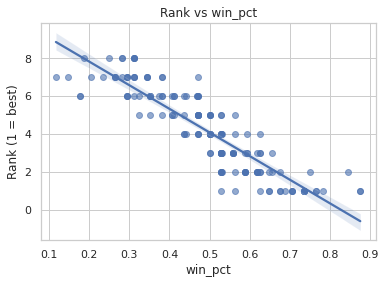

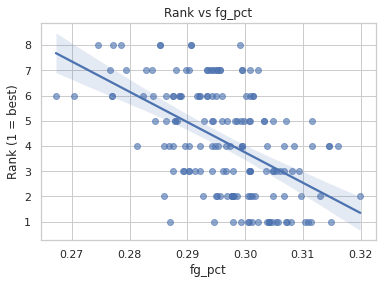

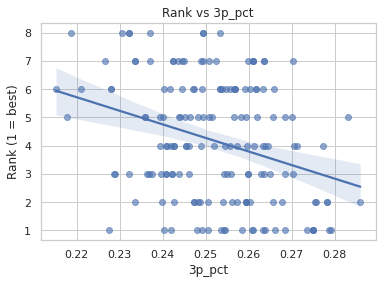

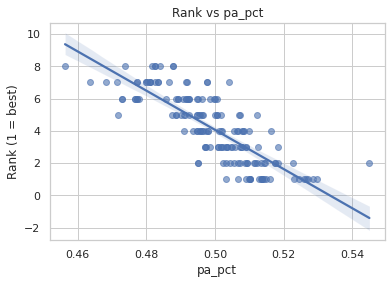

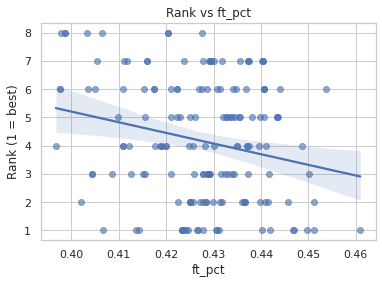

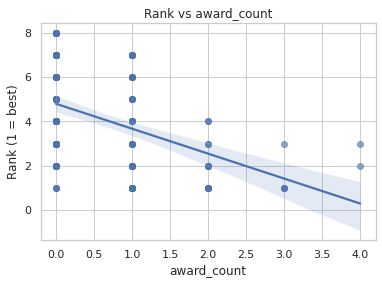

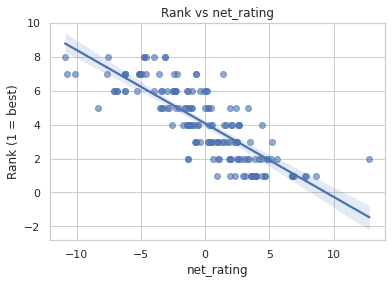

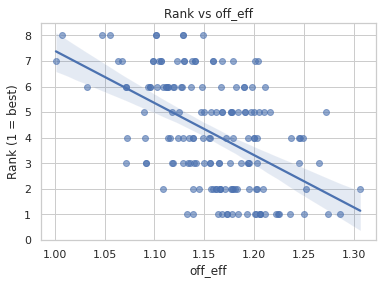

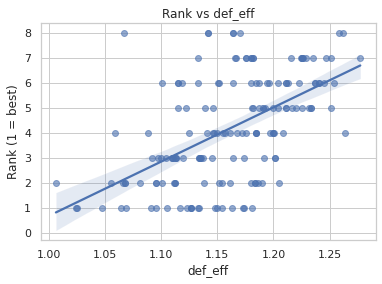

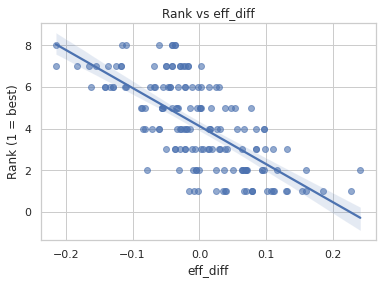

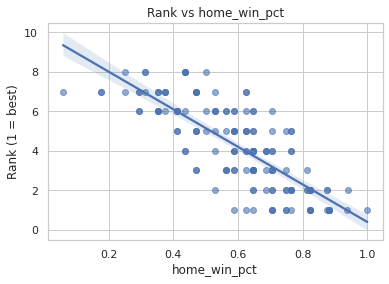

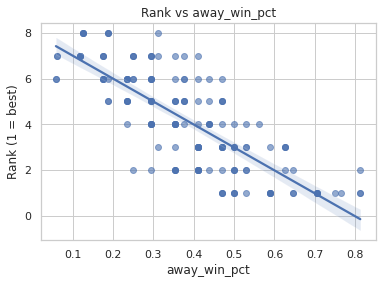

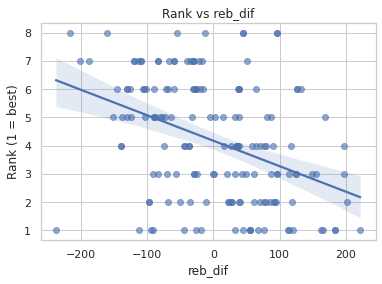

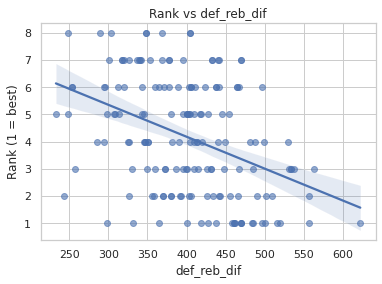

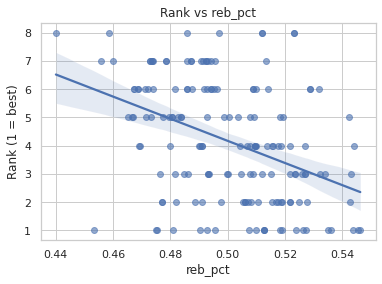

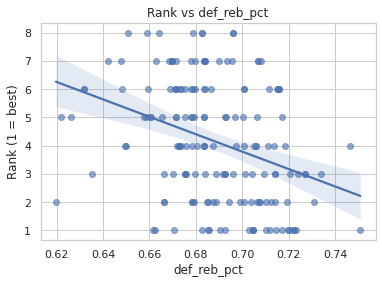

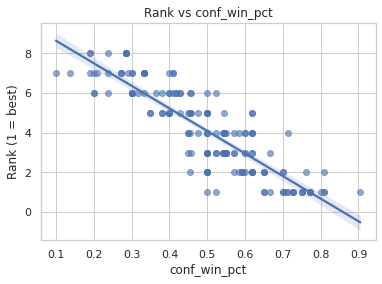

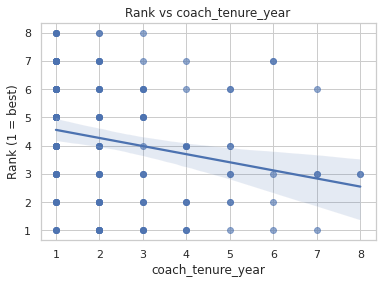

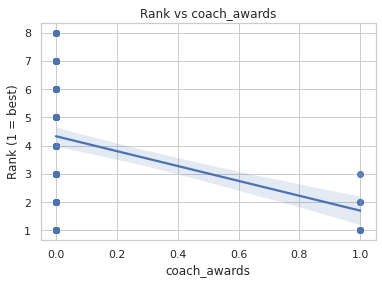

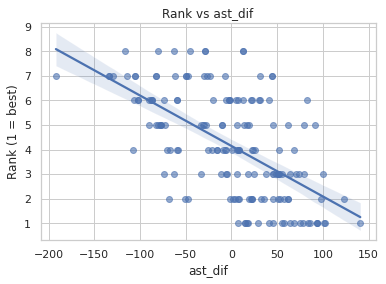

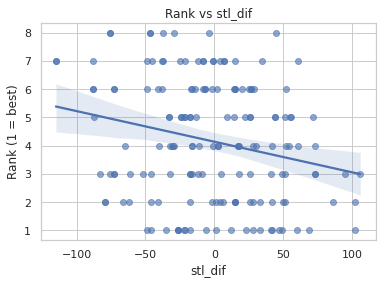

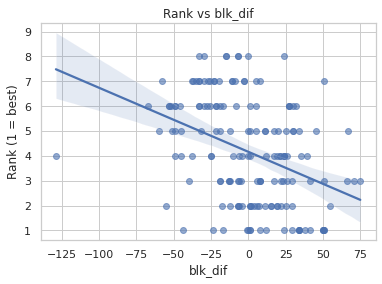

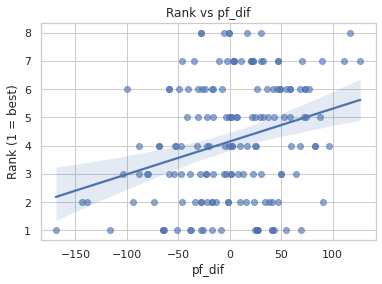

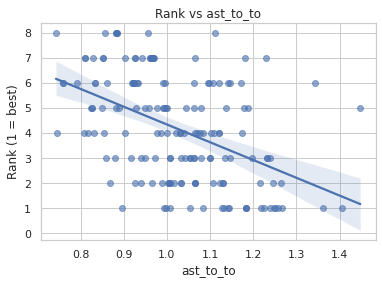

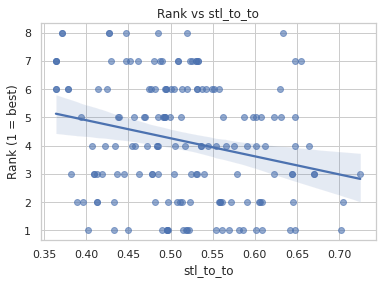

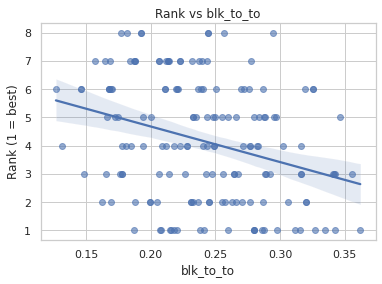

In [136]:
# Set style
sns.set(style="whitegrid", context="notebook")

for col in strong_corr.index:
    if col == "rank":
        continue
    
    plt.figure(figsize=(6, 4))
    sns.regplot(x=col, y="rank", data=df, scatter_kws={"alpha":0.6})
    plt.title(f"Rank vs {col}")
    plt.xlabel(col)
    plt.ylabel("Rank (1 = best)")
    plt.show()

In [137]:
# Train model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Dataframe of predictors
x = df[feature_cols]

# Target variable
y = df["rank"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")

rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

Mean squared error: 1.0654
Root mean squared error: 1.0322
